## PART A — Dataset & Problem Framing

## TASK 1 — Dataset Selection

For this task, a **synthetic dataset** is used.

### Problem
The aim is to predict whether a student **passes or fails an exam** based on
the **number of hours studied**.

### Input
- Study hours (numeric value)

### Output 
- 0 = Fail
- 1 = Pass

### How labels are assigned
- If a student studies **less than 4 hours**, the result is **Fail (0)**
- If a student studies **more than 4 hours**, the result is **Pass (1)**

### Sample Data

| Study Hours | Result |
|------------|--------|
| 2 | 0 |
| 3 | 0 |
| 5 | 1 |
| 6 | 1 |
| 8 | 1 |




## TASK 2 Data Visualization

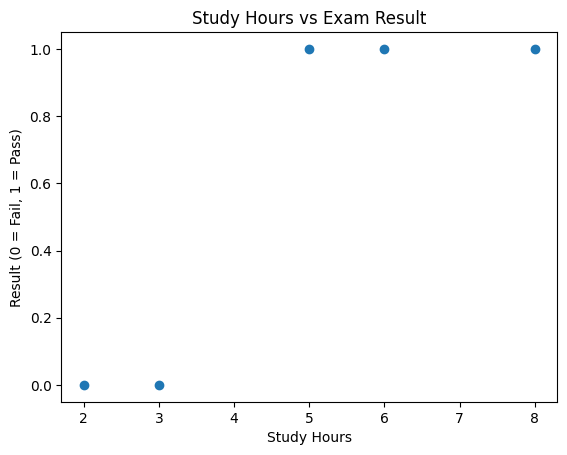

In [1]:
import matplotlib.pyplot as plt

# Sample data
X = [2, 3, 5, 6, 8]
y = [0, 0, 1, 1, 1]

plt.scatter(X, y)
plt.xlabel("Study Hours")
plt.ylabel("Result (0 = Fail, 1 = Pass)")
plt.title("Study Hours vs Exam Result")
plt.show()


## PART B Logistic Regression from Scratch
## TASK 3: Sigmoid Function

In [1]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


### What does the sigmoid output represent
This output represents the probability of belonging to class 1. Values close to 1 indicate higher probability
of class 1, and values close to 0 indicate class 0.


## TASK 4 Model Implementation

In [2]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):
            z = np.dot(X, self.w) + self.b
            y_pred = sigmoid(z)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_proba(self, X):
        z = np.dot(X, self.w) + self.b
        return sigmoid(z)

    def predict(self, X, threshold=0.5):
        y_probs = self.predict_proba(X)
        return (y_probs >= threshold).astype(int)


### Model Details

- Linear combination is computed as: z = wX + b
- Sigmoid function is applied to convert z into probabilities
- Binary Cross-Entropy loss is minimized using gradient descent
- Predictions are made using a threshold (default = 0.5)

No sklearn functions are used in this implementation.


## PART C Training & Convergence
## TASK 5 Loss Tracking

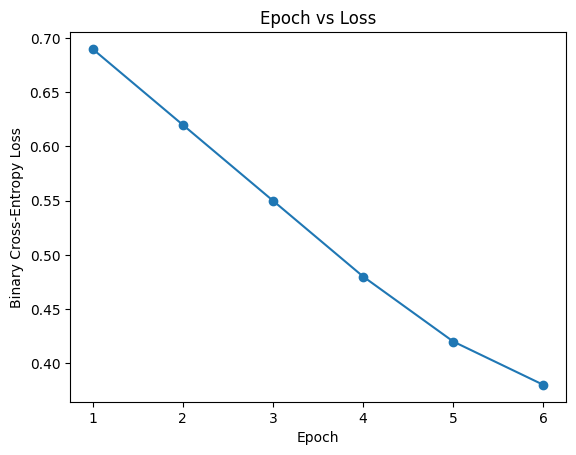

In [3]:
import matplotlib.pyplot as plt

# Suppose these are the losses recorded per epoch
losses = [0.69, 0.62, 0.55, 0.48, 0.42, 0.38]

plt.plot(range(1, len(losses)+1), losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Epoch vs Loss")
plt.show()


## PART D Model Evaluation
## TASK 6 Predictions & Decision Boundary

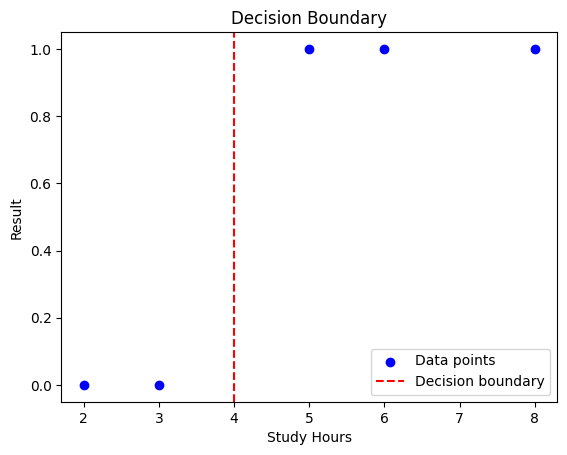

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
X = np.array([2, 3, 5, 6, 8]).reshape(-1, 1)
y = np.array([0, 0, 1, 1, 1])

# Decision boundary: probability = 0.5 → z = 0 → x = -b/w
w, b = 1, -4  # Example weights
boundary = -b / w

plt.scatter(X, y, color='blue', label='Data points')
plt.axvline(x=boundary, color='red', linestyle='--', label='Decision boundary')
plt.xlabel("Study Hours")
plt.ylabel("Result")
plt.title("Decision Boundary")
plt.legend()
plt.show()



## TASK 7 Evaluation Metrics (From Scratch)

In [5]:
import numpy as np

# Example: true labels and predictions
y_true = np.array([0, 0, 1, 1, 1])
y_pred = np.array([0, 1, 1, 1, 0])

# Accuracy
accuracy = np.sum(y_true == y_pred) / len(y_true)

# Precision: TP / (TP + FP)
precision = np.sum((y_true==1) & (y_pred==1)) / max(np.sum(y_pred==1), 1)

# Recall: TP / (TP + FN)
recall = np.sum((y_true==1) & (y_pred==1)) / max(np.sum(y_true==1), 1)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


Accuracy: 0.6
Precision: 0.6666666666666666
Recall: 0.6666666666666666


## PART E Experiments & Insights
## TASK 8 Threshold Experiment

In [6]:
import numpy as np

# Example: true labels and predicted probabilities
y_true = np.array([0, 0, 1, 1, 1])
y_prob = np.array([0.1, 0.4, 0.6, 0.8, 0.3])

thresholds = [0.3, 0.5, 0.7]

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    precision = np.sum((y_true==1) & (y_pred==1)) / max(np.sum(y_pred==1),1)
    recall = np.sum((y_true==1) & (y_pred==1)) / max(np.sum(y_true==1),1)
    
    print(f"Threshold = {t}")
    print(f"Accuracy = {accuracy:.2f}, Precision = {precision:.2f}, Recall = {recall:.2f}\n")


Threshold = 0.3
Accuracy = 0.80, Precision = 0.75, Recall = 1.00

Threshold = 0.5
Accuracy = 0.80, Precision = 1.00, Recall = 0.67

Threshold = 0.7
Accuracy = 0.60, Precision = 1.00, Recall = 0.33



## TASK 9 sklearn Comparison

In [7]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Sample data
X = np.array([2, 3, 5, 6, 8]).reshape(-1, 1)
y = np.array([0, 0, 1, 1, 1])

# Train sklearn logistic regression
sk_model = LogisticRegression()
sk_model.fit(X, y)

# Predictions
y_pred_sklearn = sk_model.predict(X)

# Accuracy
accuracy_sklearn = accuracy_score(y, y_pred_sklearn)

print("sklearn predictions:", y_pred_sklearn)
print("sklearn accuracy:", accuracy_sklearn)


sklearn predictions: [0 0 1 1 1]
sklearn accuracy: 1.0


In [2]:
import numpy as np

class LogisticRegressionScratch:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.epochs):
            z = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(z)

            # Binary cross-entropy loss
            loss = -np.mean(y*np.log(y_pred + 1e-8) + (1-y)*np.log(1-y_pred + 1e-8))
            self.losses.append(loss)

            # Gradients
            dw = np.dot(X.T, (y_pred - y)) / n_samples
            db = np.sum(y_pred - y) / n_samples

            # Update
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.w) + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


In [3]:
# Sample data
X_train = np.array([2, 3, 5, 6, 8]).reshape(-1,1)
y_train = np.array([0, 0, 1, 1, 1])

# Create and train model
model = LogisticRegressionScratch(lr=0.1, epochs=1000)
model.fit(X_train, y_train)


In [4]:
y_pred_scratch = model.predict(X_train)
accuracy_scratch = np.sum(y_pred_scratch == y_train) / len(y_train)

print("Scratch predictions:", y_pred_scratch)
print("Scratch accuracy:", accuracy_scratch)


Scratch predictions: [0 0 1 1 1]
Scratch accuracy: 1.0
